# Gender violence in Spain 2020 - 2024

This is a statistical analysis of a real [dataset](https://www.kaggle.com/datasets/ghitaes/gender-violence-spain-dataset-20202024?select=README.md) that colects statistical information of all spanish regions from 2020 to 2024.

## Dataseet load and verification

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

pd.options.display.float_format = '{:,.2f}'.format

In [2]:
df = pd.read_csv("./../../Datasets/Gender_Violence_Spain.csv")
df.head()

,Region,Year,Violence_Victims,Complaints,Funding_EUR,School_Leaving(%),Unemployment_Rate(%)
0,Andalucía,2020,6813,30847,"€ 15,286,964.44",21.80,22.30
1,Aragón,2020,725,3277,"€ 4,657,150.64",14.20,11.70
2,Asturias,2020,622,2650,"€ 2,873,028.43",8.90,14.10
3,Baleares,2020,1002,5880,"€ 4,142,542.43",21.30,16.10
4,Canarias,2020,1734,8926,"€ 5,921,683.67",18.20,22.60


**Column meanings**

- **Region:** Autonomous province or city.
- **Year:** Statistics year
- **Violence_Victims:** Number of recorded gender violence victims
- **Complaints:** Number of formal complaints filed
- **Funding_EUR:** Government funding allocated in euros (no data for País Vasco and Navarra)
- **School_Leaving(%):** Percentage of students that leave school before completion.
- **Unemployment_Rate(%):** Percentage of people without a job.

A count of regions is mage to check amount and name consistency

In [3]:
df["Region"].value_counts()

Region
Andalucía               5
Aragón                  5
Asturias                5
Baleares                5
Canarias                5
Cantabria               5
Castilla y Leon         5
Castilla-La Mancha      5
Cataluña                5
Comunitat Valenciana    5
Extremadura             5
Galicia                 5
Madrid                  5
Murcia                  5
Navarra                 5
País Vasco              5
La Rioja                5
Ceuta                   5
Melilla                 5
Name: count, dtype: int64

The column Funding_EUR is formated and converted to float

In [ ]:
df['Funding_EUR'] = (
    df['Funding_EUR']
    .str.replace('€', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

The column Funding_EUR is checked to see if data was correctly converted to float

In [5]:
df['Funding_EUR']

0    15,286,964.44
1     4,657,150.64
2     2,873,028.43
3     4,142,542.43
4     5,921,683.67
          ...     
90             NaN
91             NaN
92    1,622,397.10
93    1,611,857.02
94    1,622,397.10
Name: Funding_EUR, Length: 95, dtype: float64

In [6]:
df.describe()

,Year,Violence_Victims,Complaints,Funding_EUR,School_Leaving(%),Unemployment_Rate(%)
count,95.00,95.00,95.00,85.00,95.00,95.00
mean,"2,022.00","1,718.59","9,410.41","7,953,721.25",13.48,14.01
std,1.42,"1,813.42","10,410.72","12,899,553.39",4.58,5.53
min,"2,020.00",52.00,228.00,"1,030,425.56",5.00,5.20
25%,"2,021.00",570.50,"2,512.00","2,857,204.68",10.40,10.03
50%,"2,022.00","1,187.00","6,052.00","5,795,431.44",13.10,12.30
75%,"2,023.00","1,907.50","8,964.00","8,793,131.88",16.60,16.20
max,"2,024.00","8,407.00","39,990.00","116,666,598.59",26.00,30.85


## Statistics per year

### Victims per year

In [7]:
vv_year = df.groupby("Year")["Violence_Victims"].sum().reset_index()
vv_year

,Year,Violence_Victims
0,2020,29215
1,2021,30141
2,2022,32644
3,2023,36582
4,2024,34684


/tmp/ipykernel_5094/1389579124.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0, 0.5, 'Number of victims')

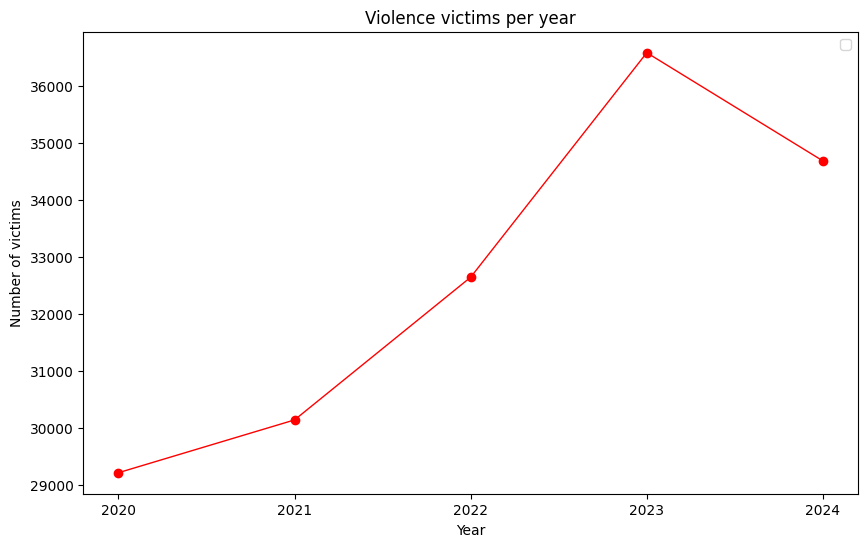

In [8]:
fig = plt.figure(figsize=(10, 6), dpi=100)
ax = fig.gca()

ax.plot(vv_year["Year"],vv_year["Violence_Victims"],marker="o", color="red", linewidth=1)
ax.set_xticks(vv_year["Year"]) # Force years to appears as in table, that is without decimals 

ax.legend()
ax.set_title("Violence victims per year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of victims")

### Complaints per year

In [9]:
cp_year = df.groupby("Year")["Complaints"].sum().reset_index()
cp_year

,Year,Complaints
0,2020,150804
1,2021,162848
2,2022,182078
3,2023,199166
4,2024,199093


/tmp/ipykernel_5094/1398269646.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0, 0.5, 'Number of complaints')

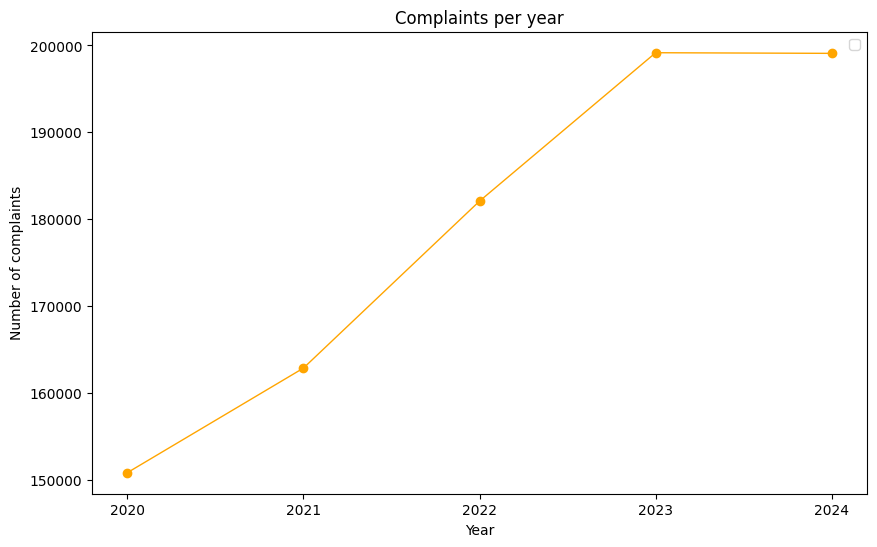

In [10]:
fig = plt.figure(figsize=(10, 6),dpi=100)
ax = fig.gca()

ax.plot(cp_year["Year"],cp_year["Complaints"],marker="o", color="orange", linewidth=1)
ax.set_xticks(cp_year["Year"])

ax.legend()
ax.set_title("Complaints per year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of complaints")

### Funding per year

Navarra and País Vasco are excluded because this regions don't have data on funding, then a new column is made to represent the amount in a short format of million.

In [11]:
fund_year = df[~df["Region"].isin(["Navarra","País Vasco"])]
fund_year = fund_year.groupby("Year")["Funding_EUR"].sum().reset_index()
fund_year['Funding_M'] = fund_year['Funding_EUR'] / 1_000_000
fund_year

,Year,Funding_EUR,Funding_M
0,2020,"99,644,696.82",99.64
1,2021,"196,508,615.56",196.51
2,2022,"100,000,000.00",100.00
3,2023,"140,202,020.01",140.20
4,2024,"139,710,974.25",139.71


/tmp/ipykernel_5094/3354164666.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0, 0.5, 'Funding (Million €)')

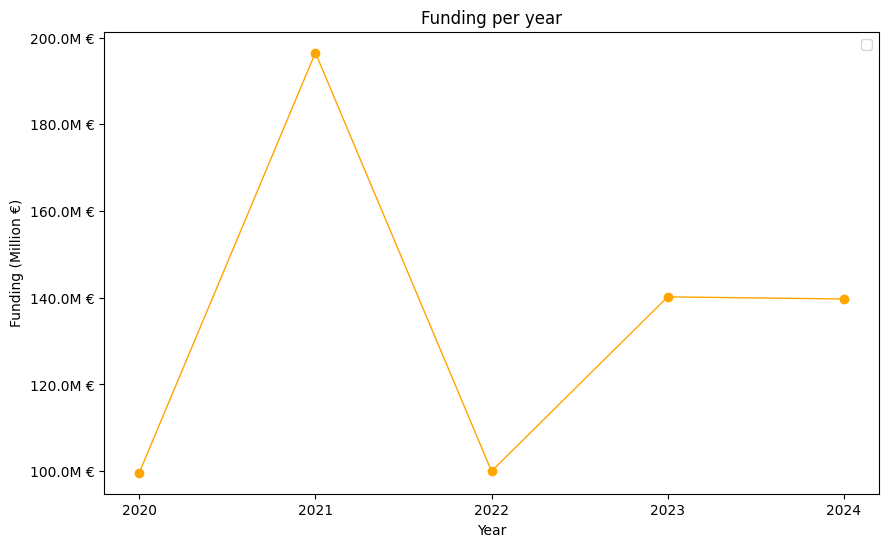

In [12]:
fig = plt.figure(figsize=(10, 6),dpi=100)
ax = fig.gca()

ax.plot(fund_year["Year"],fund_year["Funding_M"],marker="o", color="orange", linewidth=1)
ax.set_xticks(fund_year["Year"])

# This ads the format M € to every label in Y axis
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f}M €')) 

ax.legend()
ax.set_title("Funding per year")
ax.set_xlabel("Year")
ax.set_ylabel("Funding (Million €)")

## Statistics per region

### Victims per region

A pivot table is made to obtain the amount of victims per region in every year

In [13]:
pivot_victims = df.pivot_table(
    index='Region',
    columns='Year',
    values='Violence_Victims',
    aggfunc='sum'
)

A heat map is made to visualice the regions with highest amount of victims in every year

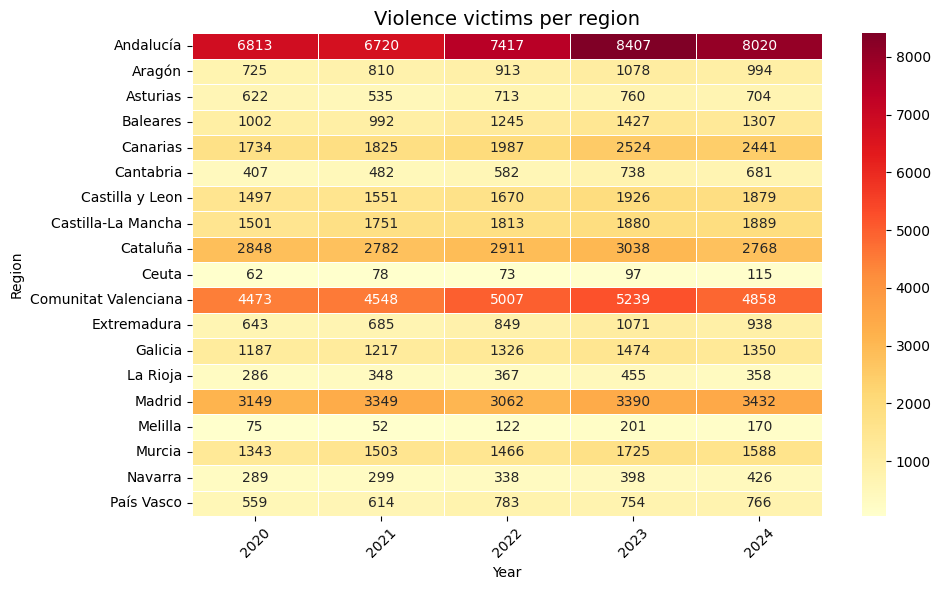

In [14]:
fig, ax = plt.subplots(figsize=(10, 6),dpi=100)

sns.heatmap(
    pivot_victims,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('Violence victims per region', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Region')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Complaints per region

In [15]:
pivot_comp = df.pivot_table(
    index='Region',
    columns='Year',
    values='Complaints',
    aggfunc='sum'
)

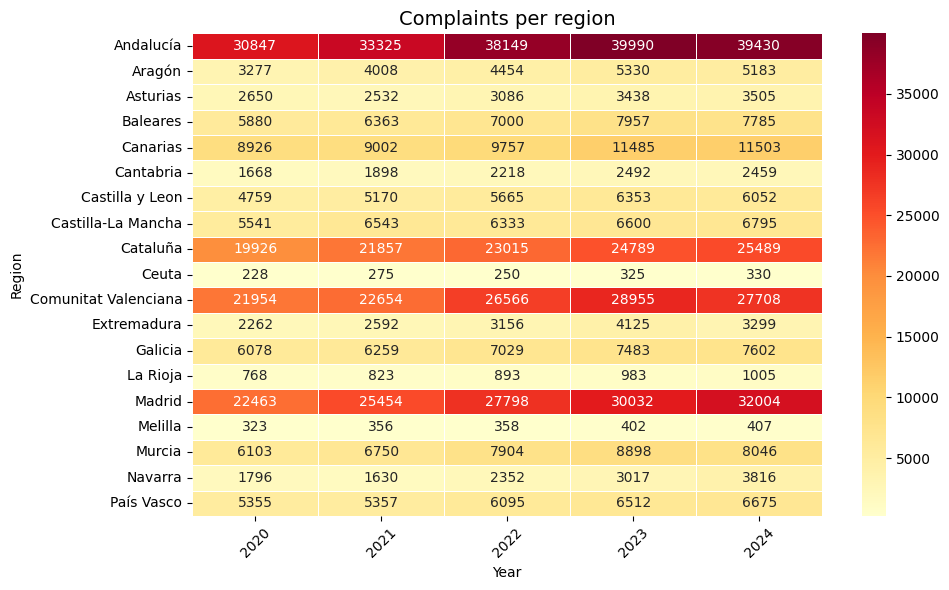

In [16]:
fig, ax = plt.subplots(figsize=(10, 6),dpi=100)

sns.heatmap(
    pivot_comp,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('Complaints per region', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Region')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Unemployment per region

In [17]:
pivot_unemp = df.pivot_table(
    index='Region',
    columns='Year',
    values='Unemployment_Rate(%)',
    aggfunc='sum'
)

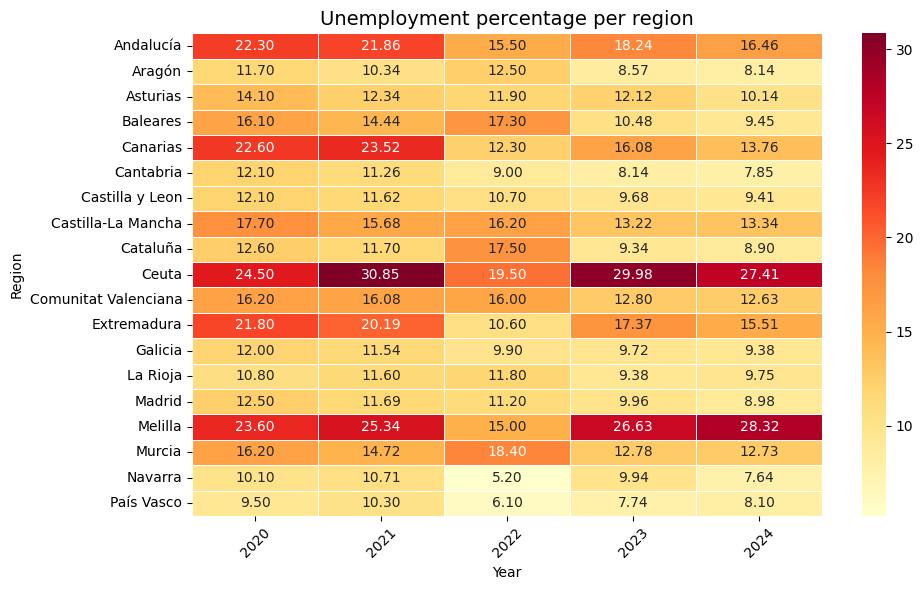

In [18]:
fig, ax = plt.subplots(figsize=(10, 6),dpi=100)

sns.heatmap(
    pivot_unemp,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('Unemployment percentage per region', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Region')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### School leave per region

In [19]:
pivot_sch_l = df.pivot_table(
    index='Region',
    columns='Year',
    values='School_Leaving(%)',
    aggfunc='sum'
)

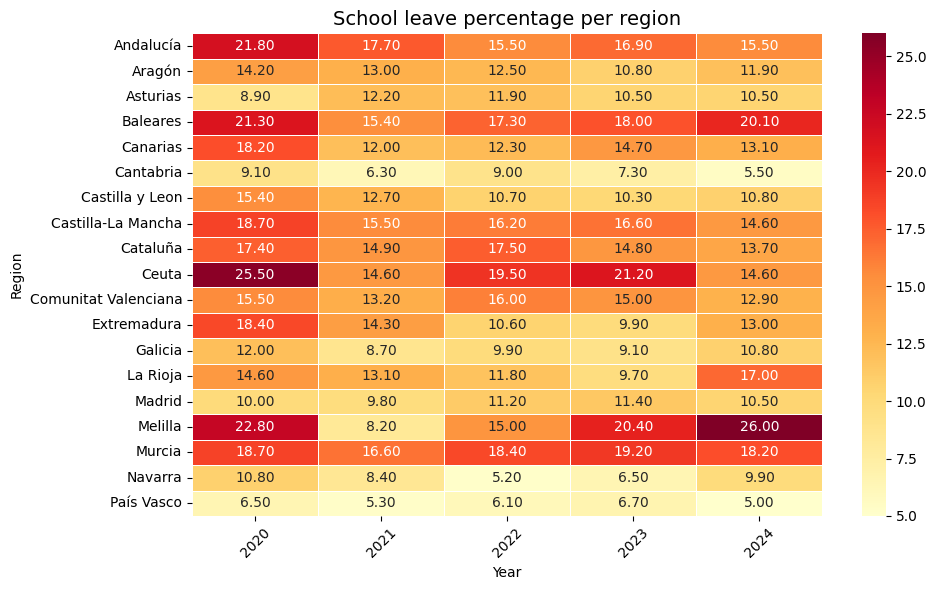

In [20]:
fig, ax = plt.subplots(figsize=(10, 6),dpi=100)

sns.heatmap(
    pivot_sch_l,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('School leave percentage per region', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Region')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusions

There is a significant increase of gender violence victims in every year since 2020 and a litle decay in 2024, the amount of complaits is directly related with the amount of victims as it increases in the same proportion as the latter. 

Funding is spread with equity among all regions, but the allocated budged for every year is inconsistent. 

When variables are analyzed in every region it can be seen a direct relation between victims amount and complaints amount, the regions that have the highest numbers in victims are the same ones in complaints. The regions with highest numbers are the following:

1. Andalucía
2. Madrid
3. Cominutat Valenciana
4. Catalunia
5. Canarias

The regions with the lowest numbers are:

1. Ceuta
2. Melilla
3. La Rioja
4. Navarra
5. Cantabria

When umployment rate per region was analyzed it couldn't be found a relation with victims and complaints, this is because some regions that have high numbers of victims and complaints like Madrid and Catalunia are on the average on umployment rate, the same case can be seen in regions with low numbers of victims and complaints like Ceuta and Melilla that have the highest numbers on umployment rate.

School leaving is not related with violence victims as most of regions have high numbers in 2020 and in the subsequent years are above the mean. 